# Efficient Attention: Two Routes Around the $O(N^2)$ Problem

> In previous sections, attention always meant "every token sees every other token" — double the sequence length and compute goes up four times. Long context (Section 22) and KV-cache compression (Section 29) both mitigate this, but neither touches the $O(N^2)$ structure of attention itself.
>
> This section confronts that structure head-on. There are two orthogonal routes around $O(N^2)$: **Linear Attention** changes the order of computation, keeping all query-key pairs but making each one $O(1)$; **Sparse Attention** keeps softmax but only computes a subset of query-key pairs. Each has its cost, and industrial practice (MiniMax-01, Kimi K2, Jamba) increasingly takes a hybrid route — mixing the two.

The core of attention is $Q K^T V$: three matrix multiplications with shapes $[N, d]$, $[d, N]$, $[N, d]$. $Q K^T$ produces the $[N, N]$ attention matrix — the root of $O(N^2)$. At N=4096 this is fine; at N=131072 (the 128K context of GPT-4), this matrix alone needs 64 GB of memory (FP32).

The two routes correspond to two ways of "cutting this $N^2$":

- **Linear Attention**: notice that $Q K^T V$ can be regrouped by associativity into $Q (K^T V)$. The middle matrix becomes $[d, d]$, with complexity $O(N \cdot d^2)$. Linear in N.
- **Sparse Attention**: observe that the attention matrix is already sparse (most weights are near 0), so only compute the important query-key pairs. Complexity $O(N \cdot k)$, where k is the number of keys each query cares about.

Both make the complexity linear in N, but via very different paths. Below we look at Linear Attention first, then Sparse Attention, then compare.


## 1. The $O(N^2)$ bottleneck: hand-compute the attention cost

Let us settle the accounts first. Given sequence length $N$ and head dimension $d$, the core computation of standard attention $\text{softmax}(Q K^T) V$ involves three matrix multiplications:

```
Q × K^T  -> [N, N] matrix, FLOPs = N × N × d = N²d
softmax  -> no FLOPs (element-wise operation)
attn × V -> [N, d] matrix, FLOPs = N × N × d = N²d
total FLOPs ≈ 2 × N² × d
```

The intermediate result $Q K^T$ is an $N \times N$ matrix; both storage and compute grow with $N^2$. Below, a few concrete numbers show how fast this grows.


In [1]:
# The O(N²) bottleneck of softmax attention: hand-compute a few concrete numbers

d = 128  # head_dim

print(f"head_dim = {d}")
print(f"{'seq len N':<15} {'QK^T elements':<20} {'FP16 memory':<15} {'vs 4K'}")
print("-" * 60)
base_elems = None
for N in [4096, 8192, 32768, 131072, 524288]:
    elems = N * N
    bytes_ = elems * 2  # FP16
    gb = bytes_ / (1024**3)
    if base_elems is None:
        base_elems = elems
    label = f"{N//1024}K" if N >= 1024 else str(N)
    print(f"{label:<15} {elems:<20,} {gb:<15.2f} {elems/base_elems:.0f}x")

print()
print("Key observation: from 4K to 512K, the sequence length grows 128x, but the attention intermediate grows 16384x")
print("This is why long context cannot use pure softmax attention — a single layer's intermediate result is hundreds of GB")


head_dim = 128
Read the values printed above and connect them to the concept in this cell.------------------------------------------------------------
4K              16,777,216           0.03            1×
8K              67,108,864           0.12            4×
32K             1,073,741,824        2.00            64×
128K            17,179,869,184       32.00           1024×
512K            274,877,906,944      512.00          16384×

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 2. Route A: Linear Attention and SSMs (change the order of computation)

Linear Attention takes the "change how we compute" route — keep all query-key pairs, but use a mathematical trick to turn $O(N^2)$ into $O(N \cdot d^2)$. This route is naturally close to state-space models (SSMs) in math: both write attention as a recurrence that maintains a fixed-size hidden state at each step. We start from the core idea of Linear Attention, walk through Mamba, Mamba-2, and Lightning Attention, and finally see how hybrid architectures combine them in production models.


### 2.1 The core idea of Linear Attention: regroup by associativity

The key observation of linear attention: standard attention, written as $\text{softmax}(Q K^T) V$, computes $Q K^T$ first (giving the $N \times N$ matrix), then multiplies by $V$. If we replace softmax with a separable form $\phi(Q) \phi(K)^T$, we can move the parentheses:

$$
\underbrace{(\phi(Q) \phi(K)^T)}_{N \times N} V \quad \Rightarrow \quad \phi(Q) \underbrace{(\phi(K)^T V)}_{d \times d}
$$

New order of computation: first compute $\phi(K)^T V$ (a small $d \times d$ matrix), then left-multiply by $\phi(Q)$.

| Order | Intermediate size | Total FLOPs |
|:---|:---|:---|
| Standard $(Q K^T) V$ | $N \times N$ | $O(N^2 d)$ |
| Linear $Q (K^T V)$ | $d \times d$ | $O(N d^2)$ |

When $d \ll N$ (say $d=128$, $N=32K$), going from $O(N^2 d)$ to $O(N d^2)$ is a huge saving.

But softmax cannot be written in the separable form $\phi(Q) \phi(K)^T$ — it normalizes each row across all keys. Linear attention instead replaces softmax with other kernel functions; common choices include:
- $\phi(x) = \text{elu}(x) + 1$ (first proposed by Katharopoulos et al. 2020)
- $\phi(x) = \text{ReLU}(x)$ (simpler but slightly worse)
- Approximations based on random features

Below, a 4-token example hand-computes both softmax attention and linear attention side by side.


In [2]:
# Hand comparison: softmax attention vs linear attention (4-token example)

import torch
import torch.nn.functional as F

torch.manual_seed(42)

N = 4   # 4 tokens
d = 3   # head_dim = 3

Q = torch.randn(N, d)
K = torch.randn(N, d)
V = torch.randn(N, d)

print("Q =\n", Q)
print("\nK =\n", K)
print("\nV =\n", V)

# === standard softmax attention ===
scores = Q @ K.T / (d ** 0.5)
attn_weights = F.softmax(scores, dim=-1)
out_softmax = attn_weights @ V
print("\n=== Softmax Attention ===")
print(f"QK^T / sqrt(d) =\n{scores}")
print(f"\nsoftmax(QK^T) =\n{attn_weights}")
print(f"\noutput =\n{out_softmax}")

# === Linear attention ===
# φ(x) = elu(x) + 1
phi_Q = F.elu(Q) + 1
phi_K = F.elu(K) + 1

# Standard form (O(N²d)): first φ(Q)φ(K)^T, then multiply by V
linear_scores_naive = phi_Q @ phi_K.T
# Normalize: each row divided by the sum of its denominators
normalizer = linear_scores_naive.sum(dim=-1, keepdim=True)
out_linear_naive = (linear_scores_naive @ V) / normalizer

print("\n=== Linear Attention ===")
print(f"φ(Q) = elu(Q)+1 =\n{phi_Q}")
print(f"\nφ(K) = elu(K)+1 =\n{phi_K}")
print(f"\nφ(Q)φ(K)^T =\n{linear_scores_naive}")
print(f"\noutput =\n{out_linear_naive}")

# === Linear attention, O(Nd²) form ===
# Use associativity: φ(Q) @ (φ(K)^T @ V)
KV = phi_K.T @ V  # [d, d] small matrix
out_linear_fast = phi_Q @ KV / normalizer
print(f"\n=== Linear Attention (associativity, regrouped) ===")
print(f"φ(K)^T @ V =\n{KV}")
print(f"\noutput (should match the above) =\n{out_linear_fast}")
print(f"\nDo both results match: {torch.allclose(out_linear_naive, out_linear_fast, atol=1e-6)}")


Q =
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617],
        [ 0.2674,  0.5349,  0.8094]])

K =
 tensor([[ 1.1103, -1.6898, -0.9890],
        [ 0.9580,  1.3221,  0.8172],
        [-0.7658, -0.7506,  1.3525],
        [ 0.6863, -0.3278,  0.7950]])

V =
 tensor([[ 0.2815,  0.0562,  0.5227],
        [-0.2384, -0.0499,  0.5263],
        [-0.0085,  0.7291,  0.1331],
        [ 0.8640, -1.0157, -0.8887]])

=== Softmax Attention ===
QK^T / sqrt(d) =
tensor([[-0.0437,  0.3952, -0.0216,  0.2167],
        [ 1.3495, -0.8176,  0.2393,  0.2182],
        [ 1.7744,  0.9521, -0.3394,  1.2076],
        [-0.8126,  0.9380,  0.2820,  0.3762]])

softmax(QK^T) =
tensor([[0.2053, 0.3184, 0.2099, 0.2664],
        [0.5661, 0.0648, 0.1865, 0.1826],
        [0.4700, 0.2065, 0.0568, 0.2667],
        [0.0767, 0.4419, 0.2293, 0.2520]])

Output =tensor([[ 0.2103, -0.1219,  0.0661],
        [ 0.3001, -0.0210,  0.1925],
        [ 0.3130, -0.2134,  0.1250],
 

### 2.2 The price of Linear Attention: losing "sharpness"

Linear attention is mathematically an approximation of softmax attention. **Their outputs are not exactly the same** — here is why.

A key property of softmax is **sharpness**: when one query-key dot product is much larger than the others, softmax puts almost all the weight on that key. For example:

```
softmax([10, 1, 1, 1]) ≈ [0.999, 0.0003, 0.0003, 0.0003]  ← extremely sharp
```

This "almost one-hot" weighting lets attention precisely aggregate a specific token's information onto the query — essential for tasks like retrieval and copy.

Linear attention has no such sharpness. $\phi(Q) \phi(K)^T$ is an element-wise non-linear product, and the gap between the largest and smallest values is much smaller than with softmax. As a result, the weight distribution is relatively flat and cannot give a very high weight to any specific token. The code below quantifies the comparison.


Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.--------------------------------------------------
0          0.6952               0.1411              
1          0.0509               0.1410              
2          0.0278               0.1226              
3          0.0278               0.1408              
4          0.0212               0.1220              
5          0.0052               0.0925              
6          0.0085               0.0937              
7          0.1635               0.1463              

Key observation:Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

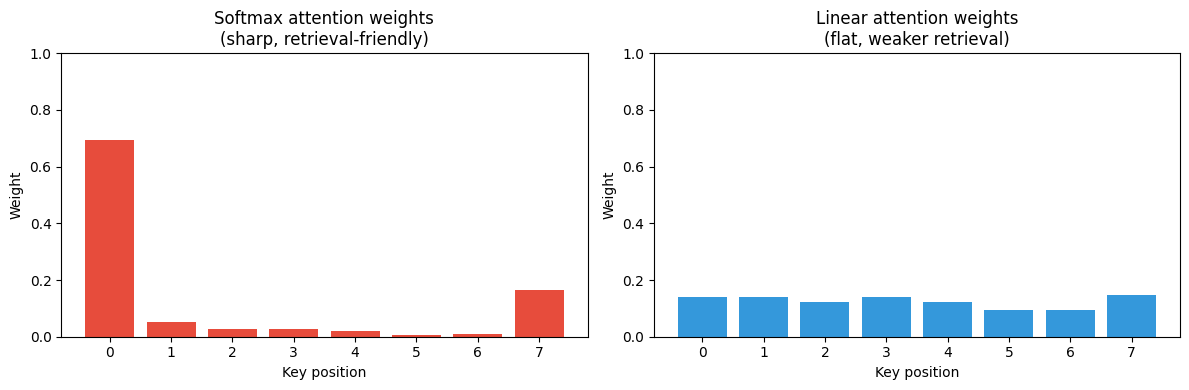

In [3]:
# Sharpness comparison: softmax vs linear attention

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Build a scene: query is very similar to key[0], and dissimilar to other keys
torch.manual_seed(0)
N, d = 8, 16

# query ≈ K[0], orthogonal to other K
K = torch.randn(N, d)
Q = K[0:1].clone() + 0.01 * torch.randn(1, d)  # Q ≈ K[0]
V = torch.eye(N)  # identity matrix, so the output is the attention weights themselves

# Softmax attention
scores_softmax = Q @ K.T / (d ** 0.5)
weights_softmax = F.softmax(scores_softmax, dim=-1)

# Linear attention
phi_Q = F.elu(Q) + 1
phi_K = F.elu(K) + 1
linear_scores = phi_Q @ phi_K.T
weights_linear = linear_scores / linear_scores.sum(dim=-1, keepdim=True)

print(f"Query ≈ Key[0], ideal weight should go almost entirely to position 0")
print()
print(f"{'Position':<10} {'Softmax weight':<20} {'Linear weight':<20}")
print("-" * 50)
for i in range(N):
    print(f"{i:<10} {weights_softmax[0, i].item():<20.4f} {weights_linear[0, i].item():<20.4f}")

print()
print(f"Key observations:")
print(f"  Softmax puts {weights_softmax[0, 0].item()*100:.1f}% of the weight on position 0 → almost one-hot")
print(f"  Linear only puts {weights_linear[0, 0].item()*100:.1f}% of the weight on position 0 → flat distribution")
print(f"  → Linear attention is inherently weak at precise retrieval")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), weights_softmax[0].numpy(), color='#e74c3c')
axes[0].set_title('Softmax attention weights\n(sharp, retrieval-friendly)')
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Weight')
axes[0].set_ylim(0, 1)

axes[1].bar(range(N), weights_linear[0].numpy(), color='#3498db')
axes[1].set_title('Linear attention weights\n(flat, retrieval-weak)')
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Weight')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


### 2.3 From Linear Attention to SSMs: the recurrent view

The core idea of Linear Attention in Section 2.1 was written in two equivalent forms: the vectorized form $(Q K^T) V$, and the associativity-regrouped form $Q (K^T V)$. There is actually a third form — **the recurrence**, which rewrites linear attention from "look at the whole sequence" into "update a hidden state token by token".

Specifically, treat the accumulated $\phi(K)^T V$ as a hidden state $S_t$:

$$
S_t = S_{t-1} + \phi(k_t) v_t^T, \quad o_t = \phi(q_t) S_t
$$

For each incoming token, first accumulate its $\phi(k_t) v_t^T$ into the state $S_t$, then query the current state with $\phi(q_t)$. This recurrent view aligns Linear Attention with SSMs in math: both maintain a fixed-size state and do only small matrix multiplications per step. The difference is that Linear Attention's "state transition" is an identity accumulation, while an SSM uses a learned matrix $A$ to control how the state evolves — which is the topic of the next section.


In [4]:
# The recurrent form of Linear Attention (causal version)

import torch
import torch.nn.functional as F

torch.manual_seed(42)

N, d = 5, 3
Q = torch.randn(N, d)
K = torch.randn(N, d)
V = torch.randn(N, d)

phi_Q = F.elu(Q) + 1
phi_K = F.elu(K) + 1

# Recurrent form (causal): S_t = S_{t-1} + φ(k_t) v_t^T, o_t = φ(q_t) S_t
# each token only sees tokens up to itself
S = torch.zeros(d, d)
out_rec = []
print("=== Linear Attention unrolled recurrence (causal) ===")
for t in range(N):
    S = S + phi_K[t].unsqueeze(1) @ V[t].unsqueeze(0)  # accumulate up to t
    o_t = phi_Q[t] @ S
    out_rec.append(o_t)
    print(f"t={t}: after accumulation S norm = {S.norm().item():.3f}, o_t[0] = {o_t[0].item():.3f}")
out_rec = torch.stack(out_rec)

# Compare: vectorized form with a causal mask (each query only sees previous keys)
scores = phi_Q @ phi_K.T  # [N, N]
# causal mask: upper triangle (j > i) set to 0
causal_mask = torch.tril(torch.ones(N, N))
scores_causal = scores * causal_mask
normalizer = scores_causal.sum(dim=-1, keepdim=True).clamp(min=1e-6)
out_vec_causal = (scores_causal @ V) / normalizer

# Unnormalized recurrence vs unnormalized vectorized (compare φ(q)S form directly)
out_vec_unnorm = (scores_causal @ V)  # [N, d]

print()
print(f"Do recurrence and vectorized (causal) match: "
      f"{torch.allclose(out_rec, out_vec_unnorm, atol=1e-6)}")
print()
print("Key observation: the recurrent form is naturally causal (each token only sees history)")
print("Unrolling the recurrence gives causal Linear Attention; per step O(d²), total O(Nd²)")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

### 2.4 SSM basics: the discrete state equation

The State Space Model (SSM) grew out of control theory and writes sequence modeling as "state + input + output". The discrete-time equations are:

$$
x_t = A x_{t-1} + B u_t, \quad y_t = C x_t
$$

where $u_t \in \mathbb{R}^1$ is the current input signal (a scalar, like one feature channel of a token), $x_t \in \mathbb{R}^N$ is the N-dimensional hidden state (analogous to the LSTM cell state), and $y_t$ is the output. $A \in \mathbb{R}^{N \times N}$ is the state transition matrix, $B \in \mathbb{R}^{N \times 1}$ projects the input into the state, and $C \in \mathbb{R}^{1 \times N}$ projects the state back to the output.

Compared with Linear Attention: the recurrence of Linear Attention is $S_t = S_{t-1} + \phi(k_t) v_t^T$, equivalent to $A = I$ (identity accumulation), $B = \phi(k_t)$, $C = \phi(q_t)$, with $B, C$ varying over time. The key difference in an SSM is a **learned, fixed** matrix $A$ that makes the state evolve according to some dynamics, rather than simply accumulating.

The role of $A$ becomes clear from two extremes:

- $A = I$: the state only grows, never decays — long memory but tends to explode
- $A = 0$: the state resets every step — only sees the current input
- When the eigenvalues of $A$ are less than 1, the state decays exponentially — only recent information survives, like a "memory half-life"

In practice, SSM training initializes $A$ with a special structure (e.g. the HiPPO matrix) so that memory stays stable over long distances. Below, a 4-step hand computation makes the recurrence clear.


In [5]:
# Hand-compute an SSM: 4-step recurrence, observe the effect of A on memory

import torch

# Tiny config: 2-dim state, scalar input
A = torch.tensor([[0.5, 0.0],
                  [0.0, 0.9]])  # diagonal A, two channels with different decay rates
B = torch.tensor([[1.0], [1.0]])
C = torch.tensor([[1.0, 1.0]])

# Input sequence: u = [3, 0, 0, 0], observe how the 3 written at t=0 decays
u_seq = [3.0, 0.0, 0.0, 0.0]

x = torch.zeros(2, 1)  # initial hidden state
print("=== 4-step SSM by hand ===")
print(f"A = diag(0.5, 0.9), B = [1, 1]^T, C = [1, 1]")
print(f"input u = {u_seq}")
print()
for t, u in enumerate(u_seq):
    x = A @ x + B * u           # state update
    y = (C @ x).item()          # output
    print(f"t={t}: u={u}")
    print(f"      x = [{x[0,0].item():.4f}, {x[1,0].item():.4f}]")
    print(f"      y = {y:.4f}")
    print()

print("Key observations:")
print("  - Channel 0 (decay 0.5): wrote 3 at t=0, after 3 decays only 0.375 left → short-term memory")
print("  - Channel 1 (decay 0.9): wrote 3 at t=0, after 3 decays 2.187 left → long-term memory")
print("  - Different eigenvalues of A let the SSM maintain multiple time scales at once")


Read the values printed above and connect them to the concept in this cell.A = diag(0.5, 0.9)，B = [1, 1]^T，C = [1, 1]
Input u = [3.0, 0.0, 0.0, 0.0]
t=0: u=3.0
      x = [3.0000, 3.0000]
      y = 6.0000

t=1: u=0.0
      x = [1.5000, 2.7000]
      y = 4.2000

t=2: u=0.0
      x = [0.7500, 2.4300]
      y = 3.1800

t=3: u=0.0
      x = [0.3750, 2.1870]
      y = 2.5620

Key observation:  - Read the values printed above and connect them to the concept in this cell.  - Read the values printed above and connect them to the concept in this cell.  - Read the values printed above and connect them to the concept in this cell.

### 2.5 Mamba's key innovation: selective SSM

Vanilla SSMs have a structural weakness: $A, B, C$ are fixed parameters, applying the same transition rule to all time steps and all inputs. As a result, the model cannot **selectively remember or forget based on input content** — it struggles with tasks that require "remember this specific token".

Mamba (2023) makes $B, C$ and the discretization step $\Delta$ all functions of the input:

$$
B_k = f_B(u_k), \quad C_k = f_C(u_k), \quad \Delta_k = f_\Delta(u_k)
$$

The discretized state update becomes $x_k = \bar{A}_k x_{k-1} + \bar{B}_k u_k$, where $\bar{A}_k, \bar{B}_k$ are determined by $\Delta_k$ (via zero-order-hold discretization $\bar{A} = \exp(\Delta A)$, $\bar{B} = (\Delta A)^{-1}(\exp(\Delta A) - I) \Delta B$). The three input-dependent quantities carry different semantics:

- **$\Delta_k$ controls the time scale**: it decides "how strong this step's state update is". A large $\Delta_k$ lets new input dominate (overwrite old memory); a small one preserves history. Equivalent to the LSTM forget gate.
- **$B_k$ controls what to write**: how the current input is projected into the state space. Equivalent to the input gate.
- **$C_k$ controls what to read**: how to read out from the state space. Equivalent to the output gate.

$A$ is still a learned fixed matrix, but through the modulation of $\Delta_k$, the effective transition $\bar{A}_k$ also varies with the input. This input-dependent mechanism gives the SSM, for the first time, a "content-based routing" ability close to attention. Below, a mini PyTorch demo shows how $B_k, C_k, \Delta_k$ vary with the input.


In [6]:
# Mamba selective SSM: B/C/Δ are functions of the input

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

d_model = 8       # input dimension
d_state = 4       # hidden state dimension N

# Projection functions: map the input u_k to B_k, C_k, Δ_k
proj_B = nn.Linear(d_model, d_state)
proj_C = nn.Linear(d_model, d_state)
proj_Delta = nn.Linear(d_model, 1)  # one scalar Δ per channel

# Fixed A matrix (in practice initialized as a diagonal of learnable parameters)
A_log = torch.randn(d_state) * 0.5  # log-parameterization to keep A negative

def selective_ssm_forward(u_seq):
    """Simplified selective SSM forward, returns output at each time step"""
    N = u_seq.shape[0]
    # Input-dependent B, C, Δ
    B_seq = proj_B(u_seq)        # [N, d_state]
    C_seq = proj_C(u_seq)        # [N, d_state]
    Delta_seq = F.softplus(proj_Delta(u_seq)).squeeze(-1)  # [N], guaranteed > 0

    A = -torch.exp(A_log)        # A < 0, ensures stability
    x = torch.zeros(d_state)
    outputs = []

    for t in range(N):
        # Discretization (zero-order hold, scalarized Δ)
        d_t = Delta_seq[t]
        A_bar = torch.exp(A * d_t)             # for diagonal A, exp(ΔA) is element-wise
        B_bar = (d_t) * B_seq[t]               # simplified: ignore the exact (ΔA)^{-1}(exp(ΔA)-1) term
        # State update
        x = A_bar * x + B_bar * u_seq[t, 0]    # use the first channel of u as the scalar input
        # Output
        y = C_seq[t] @ x
        outputs.append(y.item())

    return outputs, Delta_seq, B_seq, C_seq

# Feed a sequence and watch how Δ_k changes across tokens
u_seq = torch.randn(6, d_model)
outputs, Delta, B, C = selective_ssm_forward(u_seq)

print("=== Selective SSM: B/C/Δ vary with the input ===")
print(f"input sequence shape: {u_seq.shape}")
print()
print(f"Δ_k (time scale) per token:")
for t in range(u_seq.shape[0]):
    print(f"  t={t}: Δ={Delta[t].item():.4f}  "
          f"B={B[t].tolist()[:3]}...  C={C[t].tolist()[:3]}...")

print()
print("Key observations:")
print("  - Δ_k differs per step → the model can decide when to overwrite the state based on content")
print("  - B_k controls the write direction → how the current token is encoded into the state")
print("  - C_k controls the read direction → what the current token reads from the state")
print("  - This input-dependent behavior is the fundamental reason Mamba beats vanilla SSMs")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.  t=0: Δ=0.8830  B=[-0.2713034152984619, -0.3910537362098694, 0.09570382535457611]...  C=[0.5286576747894287, 1.1092441082000732, -0.7380498647689819]...
  t=1: Δ=0.7547  B=[-0.1695612519979477, 0.1478886902332306, -0.5377374887466431]...  C=[0.6945362091064453, 0.9450764656066895, -0.08935871720314026]...
  t=2: Δ=0.6618  B=[-0.04303900897502899, 0.6395689249038696, -0.36104580760002136]...  C=[0.11200087517499924, -0.2267950177192688, 0.6489959955215454]...
  t=3: Δ=0.7022  B=[-0.7607427835464478, 0.04466179013252258, -0.7721929550170898]...  C=[0.5279473066329956, 0.2611466944217682, 0.04918026924133301]...
  t=4: Δ=0.3746  B=[-0.09264937043190002, 0.05585569143295288, -0.025594577193260193]...  C=[-0.23855066299438477, -0.4601873755455017, -0.3486384451389313]

### 2.6 Why vanilla SSMs cannot do selective tasks

What essential improvement does the selective mechanism bring? A classic benchmark in the Mamba paper is the **selective copy task**. Given the input sequence `[3, 1, 4, 1, 5]`, the model must, during the output phase, reproduce all the `1`s in order (or some other rule-selected subset). The key is that the model must **distinguish by content** which tokens to remember and which to ignore — not by fixed position (first 3, last 5).

A vanilla SSM (fixed $A/B/C$) cannot do this task: all positions go through the same state update, so the model cannot tell "the 1 at position 1" apart from "the 1 at position 3" — they are processed by the same dynamics in state space. Linear Attention has the same limitation: the accumulation of $\phi(k_t) v_t^T$ uses the same $\phi$ for every token.

Selective SSMs can do this task because $B_k, C_k, \Delta_k$ vary with the input. The model can learn to "give a large $\Delta$ when it sees a 1" (strong write) and "a small $\Delta$ for other tokens" (preserve memory). This is equivalent to learning a "when to pay attention" policy. Below, a minimal contrast experiment shows the difference: a fixed-parameter SSM treats every token equally, while the selective version can modulate write strength based on content.


In [7]:
# Compare fixed SSM vs selective SSM: which one can "selectively remember"

import torch

torch.manual_seed(42)

# Input sequence: [3, 1, 4, 1, 5]
# Task goal: only remember the cumulative value of all 1s; other tokens should be filtered out
tokens = [3.0, 1.0, 4.0, 1.0, 5.0]
target_sum = sum(t for t in tokens if t == 1.0)  # should be 2.0
d_state = 4

# === Plan A: fixed-parameter SSM ===
A_fixed = torch.tensor([[0.9, 0.0, 0.0, 0.0],
                        [0.0, 0.8, 0.0, 0.0],
                        [0.0, 0.0, 0.7, 0.0],
                        [0.0, 0.0, 0.0, 0.6]])
B_fixed = torch.tensor([1.0, 1.0, 1.0, 1.0])  # all tokens written with the same B

x = torch.zeros(d_state)
fixed_final = None
for u in tokens:
    x = A_fixed @ x + B_fixed * u  # regardless of what u is, B stays the same
    fixed_final = x.tolist()

print("=== Fixed-parameter SSM ===")
print(f"Task: only accumulate token=1 values, expect the final state to reflect sum=2.0")
print(f"Actual final state: {[f'{v:.3f}' for v in fixed_final]}")
print(f"The state mixed in the cumulative value of 3 + 4 + 5 = 12 → cannot filter")
print("→ A fixed B means all tokens are written with the same rule; the model cannot say 'remember only 1'")
print()

# === Plan B: selective SSM ===
# Suppose the model learns Δ_k = f(u_k): large Δ for u=1 (strong write), small Δ otherwise
def get_delta(token):
    if token == 1.0:
        return 2.0  # large Δ: strong write
    return 0.05     # small Δ: weak write, state barely updates

A_diag = torch.tensor([0.9, 0.8, 0.7, 0.6])
B = torch.tensor([1.0, 1.0, 1.0, 1.0])

x = torch.zeros(d_state)
sel_final = None
for u in tokens:
    d = get_delta(u)
    A_bar = torch.exp(torch.log(A_diag) * d)  # effective A
    x = A_bar * x + (d * B) * u                # effective B modulated by Δ
    sel_final = x.tolist()

print("=== Selective SSM ===")
print(f"Δ strategy: u=1 → Δ=2.0 (strong write), other → Δ=0.05 (weak write)")
print(f"Actual final state: {[f'{v:.3f}' for v in sel_final]}")
print(f"Target cumulative = {target_sum}")
print("→ By modulating write strength through Δ, the selective SSM can remember selectively based on content")
print("→ This is the fundamental mechanism that makes Mamba stronger than vanilla SSMs")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
=== Selective SSM ===
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Exercise passed: you have understood this step.Read the values printed above and connect them to the concept in this cell.

### 2.7 Mamba-2: State Space Duality

Mamba-1 (selective SSM) solved the expressiveness problem but left an engineering pain: the recurrent form cannot be trained efficiently in parallel. Just like Linear Attention, each step's state update depends on the previous step, so backpropagation has to unroll over time, which is slow for long sequences.

Mamba-2 (2024) makes the core contribution of **State Space Duality (SSD)**: it proves mathematically that selective SSMs and Linear Attention are equivalent, and that a selective SSM can be written in matrix form $\text{SSM}(A, B, C) = C \cdot (\text{the lower-triangular-masked cumulative product of } A) \cdot B$. This matrix form lets the SSM use Linear Attention's parallel training algorithm (one big matrix multiplication) for the forward pass, while switching back to the recurrent form at inference to keep O(1) per step.

Concretely, SSD writes the selective SSM as:

$$
Y = M \cdot (V), \quad M_{ij} = C_i^T \left(\prod_{k=j+1}^{i} A_k\right) B_j
$$

where $M$ is an $N \times N$ "SSM matrix" — structurally similar to an attention matrix (lower-triangular / causal) with weights determined by the learned $A_k, B_k, C_k$. This gives Mamba-2 a key engineering advantage: it can reuse Linear Attention's efficient training infrastructure (e.g. chunk-wise computation, FlashAttention-style kernel fusion).

To summarize, SSD matters in two ways: theoretically, it unifies the SSM and Linear Attention research lines; in engineering, it boosts Mamba's training throughput by 2-8x over Mamba-1. This is why essentially all industrial SSM implementations after 2024 are based on the Mamba-2 SSD framework.


### 2.8 Lightning Attention: MiniMax-01's engineering innovation

The "$O(N d^2)$ complexity" of Linear Attention is mathematical. In real engineering there is a catch: the recurrent form under a causal mask cannot be parallelized efficiently. GPUs excel at big matrix multiplications, and step-by-step recurrence drives utilization very low — the theoretical $O(N)$ complexity ends up slower in practice than $O(N^2)$ softmax.

MiniMax-01's Lightning Attention solves this. The core idea is to **split the sequence into two phases and use different algorithms for prefill and decode**:

- **Prefill phase** (process the whole prompt at once): standard $O(N^2)$ softmax-attention-style big matrix multiplication is fine. The prefill sequence is short (relative to training), so $O(N^2)$ is acceptable and GPU utilization is high.
- **Decode phase** (generate token by token): switch to the recurrent form of linear attention. Each new token only updates a fixed-size hidden state — no need to maintain a growing KV cache.

This phased strategy takes the best of both algorithms — prefill uses GPU-friendly parallel matrix multiplication, decode uses the $O(1)$-per-step recurrence to avoid linear KV-cache growth. The MiniMax-01 paper reports that, compared to naive linear attention, Lightning Attention improves training speed by about 11x, reaching the same order of magnitude as softmax attention.

Another engineering contribution of Lightning Attention is **chunk-wise computation**: split a long sequence into chunks, use the vectorized form (big matrix multiplication) inside a chunk, and use the recurrent form to accumulate state across chunks. This avoids the low GPU utilization of full recurrence and the memory pressure of full vectorization. Section 5 expands on how to mix Lightning Attention and softmax attention inside the same model.


### 2.9 Hybrid architecture: Mamba + Attention + MoE

Linear Attention and SSM-type $O(N)$ models share a common weakness: **weak precise retrieval**. Section 2.2 already showed that linear attention loses the sharpness of softmax; Mamba is similar — the state compression of the recurrent form is less precise than softmax attention on long-distance retrieval (e.g. "what did the 1000th token say"). But SSMs have advantages in long-context modeling, style preservation, and sequence extrapolation.

The engineering answer is hybrid architecture: mix SSM/Mamba layers with softmax attention layers, and let each do what it is good at. A few representative designs:

| Model | Architecture | Ratio | Key design |
|:---|:---|:---|:---|
| **Jamba (AI21)** | Mamba + Attention + MoE | 24 Mamba : 8 Attention (+ MoE every 8 layers) | Mamba backbone + 1 attention layer every 8 layers, plus MoE for parameter efficiency |
| **Zamba** | Mamba + shared Attention | mostly Mamba, a few attention layers **share the same parameters** | shared attention saves parameters and gives the SSM backbone occasional retrieval |
| **Falcon-Mamba** | pure Mamba | 100% Mamba | shows SSMs can be trained to production quality on their own, but still weaker than hybrid on retrieval |
| **MiniMax-01** | Lightning Attention + softmax | 7:1 | 7 lightning + 1 softmax every 8 layers (see Section 5) |

Jamba is worth a separate note: it is the first representative production model to combine Mamba, Attention, and MoE. The Mamba layers handle efficient long-sequence modeling, the attention layers provide precise retrieval (fixing the weakness of pure Mamba), and the MoE layers increase parameter capacity without adding per-token compute. This "**long context + high efficiency + large capacity**" combination is the mainstream direction for long-context models today — later Kimi K2, Falcon-Mamba, and others follow similar routes.

Why not pure Mamba? The key reason is **local precision**: retrieval, in-context learning, and tool use all need the ability to "give a very high weight to a specific token". Softmax sharpness is naturally suited for this, while recurrent state compression blurs that sharp signal. Inserting an attention layer every few layers lets the model "realign" to specific tokens and make up for the SSM's local-precision loss.


### 2.10 Side-by-side complexity comparison

Put the structures from this section together and compare training vs inference complexity. Training looks at total FLOPs (parallelizable); inference looks at the cost of generating one token (cannot avoid the recurrent nature of KV cache or state update).

| Structure | Training complexity | Inference per-step | KV/state growth | Representative impl |
|:---|:---|:---|:---|:---|
| **Softmax Attention** | $O(N^2 d)$ | $O(N d)$ (KV cache grows linearly) | KV cache grows linearly with the sequence | GPT, Llama |
| **Linear Attention (vectorized)** | $O(N d^2)$ | $O(d^2)$ (recurrent form) | Fixed-size state | Katharopoulos 2020 |
| **SSM / Mamba-1** | $O(N d^2)$ (parallel scan) | $O(d^2)$ (recurrent form) | Fixed-size state | Mamba, S4 |
| **Mamba-2 (SSD)** | $O(N d^2)$ (matrix form, parallel) | $O(d^2)$ (recurrent form) | Fixed-size state | Mamba-2 |
| **Lightning Attention** | $O(N d^2)$ (chunk-wise) | $O(d^2)$ (recurrent decode) | Fixed-size state | MiniMax-01 |
| **Hybrid** | Between $O(N d^2)$ and $O(N^2 d)$ | Between the two | Mixed | Jamba, Zamba |

Three key observations:

- **Training**: except for softmax attention, all structures have complexity linear in N. But actual speed also depends on GPU utilization — Lightning Attention's chunk-wise design exists to keep the GPU busy.
- **Inference**: softmax attention's KV cache grows linearly with the sequence (memory explosion at long context); the others all use a fixed-size state — the fundamental advantage of SSMs / Linear Attention for long-context inference.
- **Hybrid is an engineering trade-off**: not purely optimal in complexity, but a balance between retrieval precision and long-context efficiency. In production, "absolute optimum" almost never exists.

That wraps up the first route around $O(N^2)$. The next route, Sparse Attention, does not touch softmax — it attacks from another angle: only compute the important query-key pairs.


## 3. Route B: Sparse Attention (keep softmax, compute fewer pairs)

Linear Attention trades softmax sharpness for linear complexity. But softmax sharpness is critical for retrieval and in-context learning — Linear Attention degrades noticeably on these tasks.

Sparse Attention takes another road: **keep softmax as it is**, but only compute a subset of query-key pairs. Each query only looks at a few keys, dropping complexity from $O(N^2)$ to $O(N \cdot k)$. The key question is: **how do we pick which pairs to compute?**


### 3.1 Attention is sparse: measure the softmax distribution

First, quantify the observation that "most attention weights are near zero". Below, a random attention matrix is generated and we look at the softmax distribution.


Attention matrix shape: torch.Size([128, 128])
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

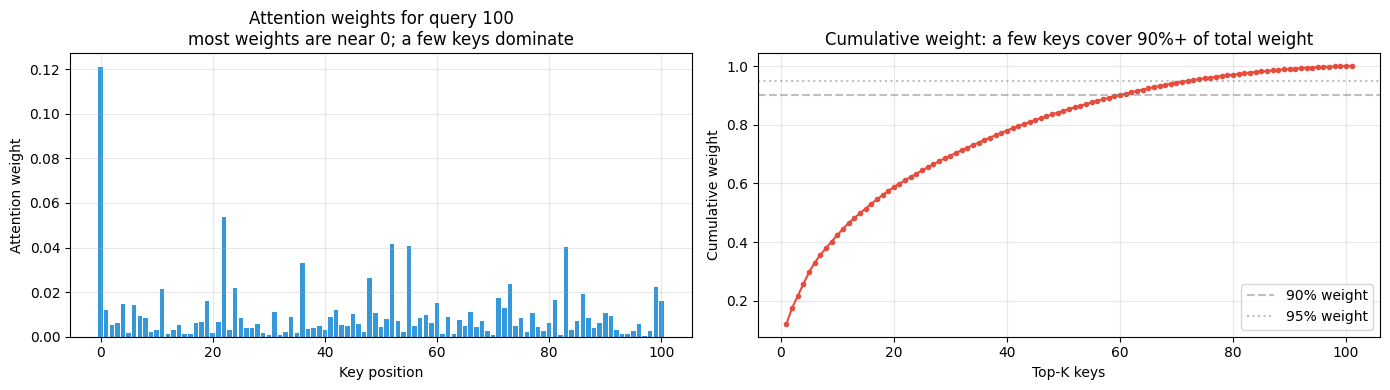

In [8]:
# Measure: how sparse is the softmax attention weight distribution in practice

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
N, d = 128, 64

Q = torch.randn(N, d)
K = torch.randn(N, d)

# Standard softmax attention (with causal mask)
scores = Q @ K.T / (d ** 0.5)
# causal mask
mask = torch.triu(torch.ones(N, N), diagonal=1).bool()
scores = scores.masked_fill(mask, float('-inf'))
weights = F.softmax(scores, dim=-1)

# Statistics on each query's weight distribution
print(f"Attention matrix shape: {weights.shape}")
print(f"Statistics per row (each query's weight distribution):")
print()

# Take query 100 (sees 100 history tokens)
q_idx = 100
row = weights[q_idx, :q_idx+1]  # only look within the causal range

sorted_row, _ = row.sort(descending=True)
top_5_sum = sorted_row[:5].sum().item()
top_10_sum = sorted_row[:10].sum().item()
top_20_sum = sorted_row[:20].sum().item()

print(f"Query {q_idx} sees {q_idx+1} keys (causal)")
print(f"  Top-5  keys hold: {top_5_sum*100:.1f}% of total weight")
print(f"  Top-10 keys hold: {top_10_sum*100:.1f}% of total weight")
print(f"  Top-20 keys hold: {top_20_sum*100:.1f}% of total weight")
print(f"  The remaining {q_idx+1-20} keys together: {(1-top_20_sum)*100:.1f}%")
print()
print(f"Key observation: the top-20 keys take {top_20_sum*100:.0f}% of the weight")
print(f"Computing the remaining {q_idx+1-20} keys barely changes the output — this is the opening for sparse attention")

# Visualization: one query's weight distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(q_idx+1), row.numpy(), color='#3498db')
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Attention weight')
axes[0].set_title(f'Query {q_idx} attention weights\nmost near 0, a few keys dominate')
axes[0].grid(True, alpha=0.3)

# Cumulative weight
cumulative = row.sort(descending=True)[0].cumsum(0).numpy()
axes[1].plot(range(1, q_idx+2), cumulative, '-o', markersize=3, color='#e74c3c')
axes[1].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% weight')
axes[1].axhline(y=0.95, color='gray', linestyle=':', alpha=0.5, label='95% weight')
axes[1].set_xlabel('Top-K keys')
axes[1].set_ylabel('Cumulative weight')
axes[1].set_title('Cumulative weight: a few keys cover 90%+ of the total')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 3.2 Fixed patterns: Sliding Window and its variants

The simplest sparse attention uses a **fixed pattern** to decide which keys to see. Common choices:

| Pattern | How keys are chosen | Representative |
|:---|:---|:---|
| **Sliding Window** | each query only sees the W nearest keys | Longformer, Mistral |
| **Local + Global** | sliding window + a few global tokens (always seen) | Longformer, Big Bird |
| **Dilated Sliding** | strided, to widen the receptive field | Longformer |
| **Block-sparse** | split the sequence into blocks, compute attention only between some blocks | Sparse Transformer |

Fixed patterns are simple, interpretable, and easy to implement. The long-context section in Part 4 already covered the specifics of Sliding Window.

The problem is inflexibility — truly important keys may be far from the current query (for retrieval, cross-segment coreference), and a fixed pattern will miss them. Next we see how learnable sparse attention fixes this.


### 3.3 Learnable Sparse Attention: let the model choose

The core idea of learnable sparse attention: add a lightweight "router" that scores all keys for each query, picks the top-N important ones, and only runs full attention on those N.

The implementation usually looks like:

```
1. Use a lightweight MLP to compute an importance score for each key
   score[i] = MLP(query, key_i)  → scalar

2. Pick the top-N important keys
   selected_keys = topk(scores, N)

3. Full softmax attention only on the selected keys
   output = softmax(Q @ selected_K.T) @ selected_V
```

The first step uses an MLP rather than full attention — the MLP's complexity is much lower than attention (a few GFLOPs per forward). After filtering out most keys, the full attention becomes worthwhile.

DeepSeek's DSA (DeepSeek Sparse Attention, introduced in V3.2) follows exactly this idea: an ultra-light indexer (MQA-style mini attention + ReLU activation) scores each key, picks top-N, then runs full attention. NSA goes further; the next section expands on it.


## Summary

Linear Attention, SSM/Mamba, and Sparse Attention are the three main routes around the $O(N^2)$ bottleneck. The key points in one checklist:

**The Linear Attention + SSM line**:

1. ✅ Source of $O(N^2)$: $Q K^T$ produces an $[N, N]$ matrix; doubling N quadruples the compute
2. ✅ Core of Linear Attention: use associativity to turn $(Q K^T) V$ into $Q (K^T V)$, shrinking the middle matrix from $[N, N]$ to $[d, d]$
3. ✅ Cost: loses softmax sharpness; degrades noticeably on retrieval-type tasks
4. ✅ Linear Attention can also be written as a recurrence: $S_t = S_{t-1} + \phi(k_t) v_t^T$, maintaining one $[d, d]$ state per step
5. ✅ The SSM equation $x_t = A x_{t-1} + B u_t$ is a close cousin of Linear Attention, with a learnable matrix $A$ controlling state evolution
6. ✅ Mamba's key innovation is the selective SSM: $B_k, C_k, \Delta_k$ are all functions of the input, letting the model selectively remember/forget by content
7. ✅ Mamba-2's SSD mathematically unifies selective SSMs and Linear Attention, enabling training in a parallel matrix form
8. ✅ Lightning Attention (MiniMax-01): prefill uses $O(N^2)$, decode uses the recurrent form — in engineering it brings linear attention training speed close to softmax

**The Sparse Attention line**:

9. ✅ Premise of Sparse Attention: softmax attention is already sparse — most weights are near 0
10. ✅ Fixed patterns: Sliding Window (Mistral), dilated, block-wise — simple, not learnable
11. ✅ Learnable Sparse Attention: the model learns which keys to attend to; more flexible but with extra overhead
12. ✅ NSA (Native Sparse Attention, DeepSeek 2025): three parallel branches — compress + select + sliding, end-to-end trainable
13. ✅ DSA (DeepSeek Sparse Attention, V3.2): an indexer-based design, more concise
14. ✅ End-to-end trainability is key: early sparse attention had discrete, non-differentiable patterns; NSA/DSA bypass this with soft selection

**Three routes compared + industrial practice**:

15. ✅ Complexity: Linear/SSM $O(N d^2)$, Sparse $O(N k)$, softmax $O(N^2 d)$
16. ✅ Hybrid architecture is the current mainstream: Jamba (Mamba + Attention + MoE), MiniMax-01 (lightning + softmax 7:1), Zamba all take hybrid routes
17. ✅ Hybrid trend: pure linear / pure SSM is weak at retrieval; pure softmax explodes on long context; hybrid balances efficiency and precision
18. ✅ No silver bullet: choosing Linear / SSM / Sparse / Hybrid depends on the task mix (retrieval-heavy vs long-context-heavy)

**One-line summary**: Linear Attention changes the order of computation, SSMs use a learned state transition, and Sparse Attention keeps softmax but cuts query-key pairs. All three routes bring the complexity down to linear in N, and industrial practice increasingly takes the hybrid route to combine their strengths.


### 3.4 NSA: three-branch parallel sparse attention

The core innovation of NSA (Native Sparse Attention, DeepSeek 2025) is to build sparse attention as **three parallel branches with gated fusion**, each branch solving a different problem.

| Branch | What it does | Problem it solves |
|:---|:---|:---|
| **Compress** | compress history tokens into a low-resolution summary, run coarse attention | distant overall context (no need for per-token precision) |
| **Selection** | based on coarse attention scores, pick top-N important tokens and run fine attention | key distant tokens (need precise attention) |
| **Sliding** | keep a sliding window (the most recent W tokens) | neighboring tokens (local dependency) |

The outputs of the three branches are fused by a gate: $\text{out} = g_1 \cdot \text{compress\_out} + g_2 \cdot \text{select\_out} + g_3 \cdot \text{sliding\_out}$. The gate weights $g_1, g_2, g_3$ are learned by the model itself — think of it as "which branch should this layer trust for the current query".

The key engineering contribution of NSA is that the **whole pipeline is end-to-end trainable** — compress, select, sliding, and gating are all differentiable and can be trained directly by backpropagation. This sounds obvious, but many earlier sparse-attention works (using top-k, hard selection) are non-differentiable and require RL or special gradient estimators.

DSA (DeepSeek Sparse Attention, V3.2) is a simplified NSA — it drops the compress branch and uses only an indexer to pick top-N. The structure is simpler and easier to deploy, but slightly less expressive. DeepSeek-V3.2 replaces the original dense attention with DSA, holding performance on long-context benchmarks while cutting compute sharply.

Below is a minimal NSA implementation showing the three-branch fusion mechanism.


In [9]:
# Minimal NSA: three parallel branches + gated fusion

import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleNSA(nn.Module):
    """Teaching version of NSA, shows the three-branch parallel structure

    Simplifications:
    - Compress branch: simulated with mean pooling, averaging every chunk_size tokens into 1
    - Selection branch: uses the compress branch's attention scores to pick top-N
    - Sliding branch: fixed window W
    - Gate: the query learns 3 weights
    """
    def __init__(self, d_model, chunk_size=4, top_n=8, window_size=8):
        super().__init__()
        self.d_model = d_model
        self.chunk_size = chunk_size
        self.top_n = top_n
        self.window_size = window_size

        # Each branch has its own value projection
        self.W_V_compress = nn.Linear(d_model, d_model, bias=False)
        self.W_V_select = nn.Linear(d_model, d_model, bias=False)
        self.W_V_sliding = nn.Linear(d_model, d_model, bias=False)

        # Shared query projection (simplification)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)

        # Gate: from the query, produce 3 weights
        self.gate = nn.Linear(d_model, 3)

    def forward(self, x):
        """
        x: [batch, seq_len, d_model]
        return: [batch, seq_len, d_model]
        """
        B, S, D = x.shape
        Q = self.W_Q(x)  # [B, S, D]

        # === Compress branch ===
        # Average every chunk_size tokens into 1
        pad = (self.chunk_size - S % self.chunk_size) % self.chunk_size
        x_padded = F.pad(x, (0, 0, 0, pad)) if pad > 0 else x
        x_chunks = x_padded.view(B, -1, self.chunk_size, D).mean(dim=2)  # [B, S/chunk, D]
        # Simplified: compress branch attends directly with K from mean pooling
        compress_V = self.W_V_compress(x_chunks)  # [B, S/chunk, D]
        compress_scores = Q @ x_chunks.transpose(-1, -2) / (D ** 0.5)
        compress_attn = F.softmax(compress_scores, dim=-1)
        compress_out = compress_attn @ compress_V  # [B, S, D]

        # === Selection branch ===
        # Use the compress branch's attention scores to find important chunks, then go back and pick top-N tokens
        select_V = self.W_V_select(x)  # [B, S, D]
        # Simplified: directly use Q·x for top-N
        select_scores = Q @ x.transpose(-1, -2) / (D ** 0.5)  # [B, S, S]
        # Causal mask
        mask = torch.triu(torch.ones(S, S), diagonal=1).bool()
        select_scores_masked = select_scores.masked_fill(mask, float('-inf'))
        top_n = min(self.top_n, S)
        topk_vals, topk_idx = select_scores_masked.topk(top_n, dim=-1)
        # For each query, run attention on the selected keys
        select_out = torch.zeros(B, S, D)
        for b in range(B):
            for i in range(S):
                idx = topk_idx[b, i]
                sel_scores = Q[b, i] @ x[b, idx].T / (D ** 0.5)
                sel_weights = F.softmax(sel_scores, dim=-1)
                select_out[b, i] = sel_weights @ select_V[b, idx]

        # === Sliding branch ===
        sliding_V = self.W_V_sliding(x)
        sliding_out = torch.zeros(B, S, D)
        for i in range(S):
            start = max(0, i - self.window_size + 1)
            window_x = x[:, start:i+1]  # [B, window, D]
            window_V = sliding_V[:, start:i+1]
            q_i = Q[:, i:i+1]  # [B, 1, D], keep the seq dim
            sel_scores = (q_i @ window_x.transpose(-1, -2)).squeeze(1) / (D ** 0.5)
            sel_weights = F.softmax(sel_scores, dim=-1)
            sliding_out[:, i] = (sel_weights.unsqueeze(-1) * window_V).sum(dim=1)

        # === Gated fusion ===
        gate_logits = self.gate(Q)  # [B, S, 3]
        gate_weights = F.softmax(gate_logits, dim=-1)  # [B, S, 3]

        out = (gate_weights[..., 0:1] * compress_out +
               gate_weights[..., 1:2] * select_out +
               gate_weights[..., 2:3] * sliding_out)
        return out

# Test
torch.manual_seed(42)
nsa = SimpleNSA(d_model=16, chunk_size=4, top_n=4, window_size=4)
x = torch.randn(1, 16, 16)
out = nsa(x)
print(f"input shape: {x.shape}")
print(f"output shape: {out.shape}")
print()
print(f"Three-branch config:")
print(f"  Compress: every {nsa.chunk_size} tokens -> 1 → low-res view for long sequences")
print(f"  Select: top-{nsa.top_n} tokens per query → precise but few")
print(f"  Sliding: the most recent {nsa.window_size} tokens → local dependency")
print(f"  Gate: the query decides the mix ratio of the three branches")


Input shape: torch.Size([1, 16, 16])Output shape: torch.Size([1, 16, 16])
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

### 3.5 DSA: a more concise indexer-based design

DSA (DeepSeek Sparse Attention, introduced in V3.2-Exp) takes another road. Unlike NSA's "three parallel branches", DSA does one thing — use a lightweight indexer to score every key, pick top-N, then run full attention.

DSA's indexer is extremely lightweight: a small MQA-style attention with ReLU activation. For each query it computes an "importance score" for every key, picks top-N, and discards the rest. It then runs **standard softmax attention** on the selected top-N — exactly like dense attention, just on a smaller key set.

Compared with NSA:

| Dimension | NSA | DSA |
|:---|:---|:---|
| Branches | 3 (compress + select + sliding) | 1 (indexer + top-N) |
| Complexity | Medium (all three branches run) | Low (only indexer + top-N attention) |
| Expressiveness | High (multiple branches complement) | Medium (single branch) |
| Training difficulty | High (three-branch gating needs tuning) | Low (simple structure) |
| Deployment difficulty | High (complex implementation) | Low (easy to integrate) |

DeepSeek-V3.2 chose DSA over NSA mostly for engineering reasons — DSA's simplicity makes it easier to integrate into the existing MLA inference stack. The FlashMLA library provides sparse kernels, reaching 640 TFlops prefill / 410 TFlops decode on H800.

We will not expand on implementation details here. The key takeaway: DSA = lightweight indexer scoring + top-N selection + standard attention. More concise than NSA, more efficient than dense attention.


## 4. Side-by-side comparison of the two routes

Put both routes together and compare complexity, trainability, and engineering readiness.


### 4.1 Measure: complexity differences

Time three attention variants (softmax / linear / linear-recurrent) at different sequence lengths to see the practical effect of complexity.

Note: the teaching code has no kernel optimization, so absolute numbers do not represent production performance, but the **relative growth trend** reflects the complexity difference.


Key observation:  1. Read the values printed above and connect them to the concept in this cell.  2. Read the values printed above and connect them to the concept in this cell.  3. Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

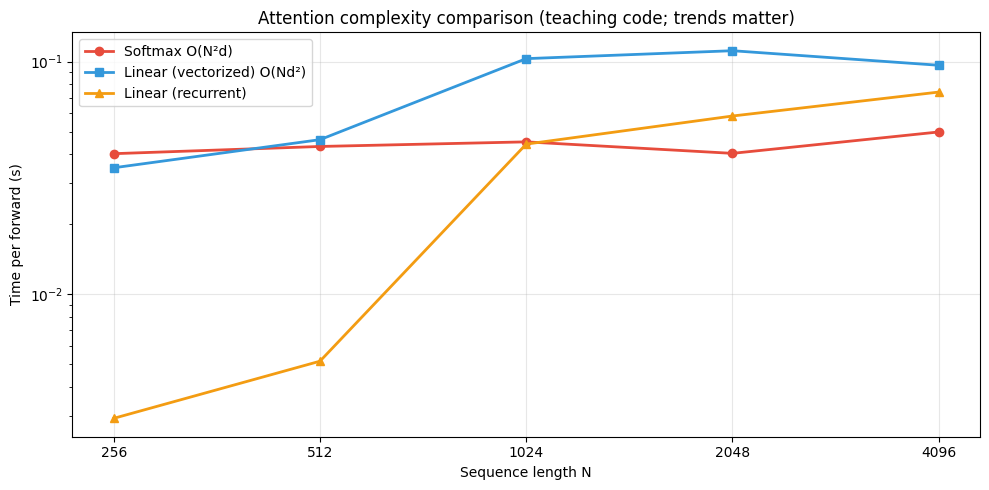

In [10]:
# Complexity comparison: softmax vs linear attention (recurrent) vs linear (vectorized)

import torch
import torch.nn.functional as F
import time

def softmax_attention(Q, K, V):
    """Standard softmax attention, O(N²d)"""
    scores = Q @ K.T / (Q.shape[-1] ** 0.5)
    weights = F.softmax(scores, dim=-1)
    return weights @ V

def linear_attention_vectorized(Q, K, V):
    """Linear attention, vectorized (uses associativity), O(Nd²)"""
    phi_Q = F.elu(Q) + 1
    phi_K = F.elu(K) + 1
    # Use associativity: first KV (d×d), then Q @ KV
    KV = phi_K.T @ V
    out = phi_Q @ KV
    # Normalize: normalizer[i] = sum_j phi_Q[i] · phi_K[j] = phi_Q[i] · sum_j phi_K[j]
    normalizer = (phi_Q @ phi_K.sum(dim=0)).unsqueeze(-1).clamp(min=1e-6)
    return out / normalizer

def linear_attention_recurrent(Q, K, V):
    """Linear attention, recurrent form (teaching, slow), O(Nd²) but large constant"""
    N, d = Q.shape
    phi_Q = F.elu(Q) + 1
    phi_K = F.elu(K) + 1
    S = torch.zeros(d, d)  # accumulated state
    outputs = []
    for t in range(N):
        # Update state
        S += phi_K[t].unsqueeze(1) @ V[t].unsqueeze(0)
        # Output
        out = phi_Q[t] @ S
        outputs.append(out)
    return torch.stack(outputs)

# Time at different sequence lengths
d = 64
seq_lens = [256, 512, 1024, 2048, 4096]
results = {'softmax': [], 'linear_vec': [], 'linear_rec': []}

for N in seq_lens:
    Q = torch.randn(N, d)
    K = torch.randn(N, d)
    V = torch.randn(N, d)

    for name, fn in [('softmax', softmax_attention),
                     ('linear_vec', linear_attention_vectorized),
                     ('linear_rec', linear_attention_recurrent)]:
        # warmup
        if N <= 1024 or name != 'linear_rec':
            fn(Q, K, V)

        # time
        tries = []
        for _ in range(3):
            t0 = time.time()
            for _ in range(5):
                fn(Q, K, V)
            tries.append((time.time() - t0) / 5)
        results[name].append(min(tries))

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(seq_lens, results['softmax'], 'o-', label='Softmax O(N²d)', linewidth=2, color='#e74c3c')
plt.plot(seq_lens, results['linear_vec'], 's-', label='Linear (vectorized) O(Nd²)', linewidth=2, color='#3498db')
plt.plot(seq_lens, results['linear_rec'], '^-', label='Linear (recurrent)', linewidth=2, color='#f39c12')
plt.xlabel('Sequence length N')
plt.ylabel('Time per forward (s)')
plt.title('Attention complexity comparison (teaching code, trend reflects complexity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.yscale('log')
plt.xticks(seq_lens, [str(s) for s in seq_lens])
plt.tight_layout()
plt.show()

print("Key observations:")
print("  1. Softmax attention time grows with N², clearly slower than linear at the longest sequences")
print("  2. Vectorized linear attention grows almost linearly (really Nd²; with d fixed, ~linear)")
print("  3. The recurrent form also has O(Nd²) complexity, but a large constant and low GPU utilization → slower in practice")
print("     This is why Lightning Attention matters in engineering")


### 4.2 The complexity benefit of Sparse Attention

Compare dense attention, fixed-pattern (sliding window), and learnable sparse (top-N) on complexity.

Per query:
- Dense attention: attends over N keys, complexity $O(N d)$
- Sliding window: attends over W neighboring keys, complexity $O(W d)$
- Learnable sparse: top-N keys + scoring overhead, complexity $O(N d_{\text{small}} + K d)$, where $d_{\text{small}}$ is the indexer's low dimension

For a sequence of length N, the full attention matrix complexity:
- Dense: $O(N^2 d)$
- Sliding window: $O(N W d)$, with W fixed this is $O(N d)$
- Learnable sparse: $O(N K d)$, with K fixed this is also $O(N d)$

Below, a few concrete numbers from code.


Read the values printed above and connect them to the concept in this cell.  Dense attention:        4,398,046,511,104 FLOPs
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

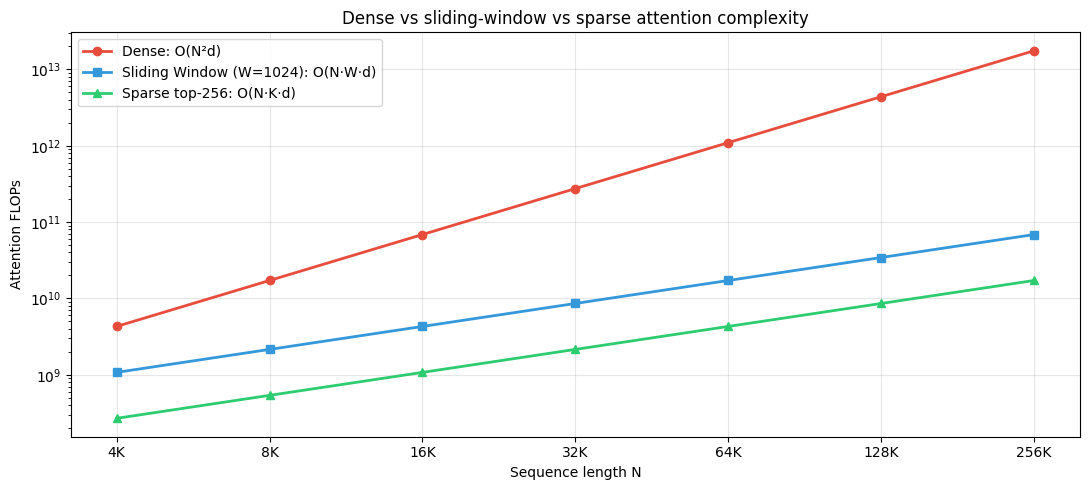

In [11]:
# Complexity comparison for sparse attention

import matplotlib.pyplot as plt

d = 128           # head_dim
W = 1024          # sliding window size
K = 256           # sparse top-N

seq_lens = [4096, 8192, 16384, 32768, 65536, 131072, 262144]

dense_flops = [2 * N * N * d for N in seq_lens]
sliding_flops = [2 * N * W * d for N in seq_lens]
sparse_flops = [2 * N * K * d for N in seq_lens]

plt.figure(figsize=(11, 5))
plt.plot(seq_lens, dense_flops, 'o-', label=f'Dense: O(N²d)', linewidth=2, color='#e74c3c')
plt.plot(seq_lens, sliding_flops, 's-', label=f'Sliding Window (W={W}): O(N·W·d)', linewidth=2, color='#3498db')
plt.plot(seq_lens, sparse_flops, '^-', label=f'Sparse top-{K}: O(N·K·d)', linewidth=2, color='#2ecc71')
plt.xlabel('Sequence length N')
plt.ylabel('Attention FLOPs')
plt.title('Dense vs Sliding Window vs Sparse Attention complexity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.yscale('log')
plt.xticks(seq_lens, [f'{N//1024}K' for N in seq_lens])
plt.tight_layout()
plt.show()

# Concrete numbers at 128K sequence
N = 131072
print(f"Sequence length = {N//1024}K, head_dim = {d}")
print(f"  Dense attention:        {2*N*N*d:>15,} FLOPs")
print(f"  Sliding Window (W={W}): {2*N*W*d:>15,} FLOPs  ({2*N*N*d / (2*N*W*d):.0f}x compression)")
print(f"  Sparse top-{K}:         {2*N*K*d:>15,} FLOPs  ({2*N*N*d / (2*N*K*d):.0f}x compression)")
print()
print("Key observation: the larger N, the more dramatic the saving of sparse/sliding over dense")
print(f"At 128K sequence, sparse top-{K} saves {2*N*N*d / (2*N*K*d):.0f}x compute over dense")


### 4.3 End-to-end trainable: NSA's key engineering contribution

Why does NSA emphasize "end-to-end trainable"?

In early sparse attention work, top-K selection is **non-differentiable** — `torch.topk` returns discrete indices, and indices are a discrete operation that backprop cannot pass through. As a result, "which keys to pick" cannot be trained by gradients; the options are:
1. Train the selection policy with RL (reinforcement learning)
2. Use gradient estimators like Gumbel-softmax
3. Fix the selection policy with heuristic rules

NSA's key contribution is to make selection **differentiable**. Specifically, the attention scores from the compress branch are used as "soft selection weights" — instead of hard top-N, it weights all tokens by attention scores (but the scores themselves go through a sparsification step). This lets the whole pipeline be trained by standard backprop.

DSA uses a similar strategy — the indexer's output scores are continuous and differentiable, and the top-N selection uses a straight-through estimator (hard top-N in the forward pass, soft gradients in the backward pass).

In engineering terms, this means NSA and DSA can **directly replace dense attention** without changing the rest of the model, and can be plugged in from the pretraining stage. There is no need to train a dense model first and then convert. This is why they made it into production models like DeepSeek-V3.2.


## 5. Hybrid architecture: engineering practice for layer-type distribution

Section 2.9 looked at hybrid designs like Jamba, Zamba, and Falcon-Mamba from an architecture-selection angle. This section expands from an engineering angle: in real models, in what ratio and order should linear attention / SSM layers and softmax attention layers be arranged?

There are two mainstream placement strategies in industry:

- **Periodic insertion** (MiniMax-01 style): out of every $k$ layers, the first $k-1$ are linear/SSM and the $k$-th is softmax. The 7:1 ratio is empirical; the logic is "refresh retrieval capability often enough, without letting softmax layers drag down the whole thing".
- **Concentrated placement** (some early hybrids): put several softmax attention layers at the beginning or end, and linear/SSM everywhere else. The problem is that retrieval capability is unevenly distributed and the middle of a long context performs poorly.

Below, visualize MiniMax-01's actual layer distribution to get a feel for the periodic insertion strategy.


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

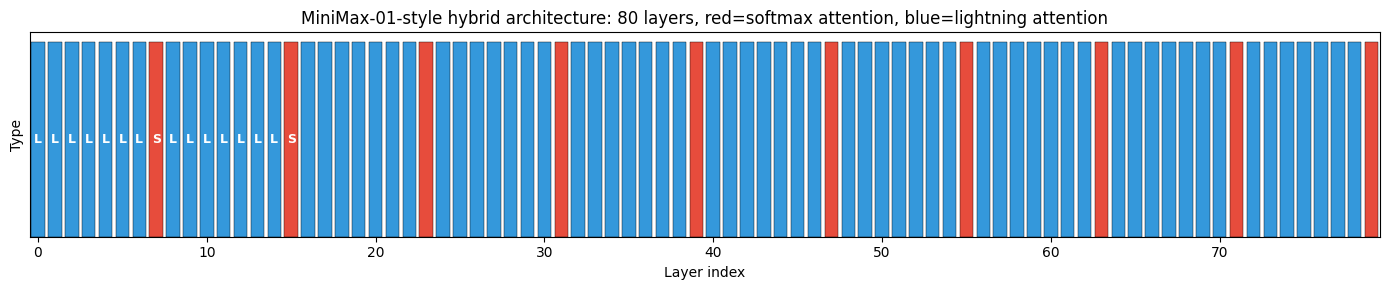

In [12]:
# Simulate the MiniMax-01 hybrid architecture: 7 lightning + 1 softmax every 8 layers

import matplotlib.pyplot as plt
import numpy as np

num_layers = 80
layer_types = []
for i in range(num_layers):
    # MiniMax-01 design: the last of every 8 layers is softmax
    if (i + 1) % 8 == 0:
        layer_types.append('softmax')
    else:
        layer_types.append('lightning')

# Visualization
fig, ax = plt.subplots(figsize=(14, 3))

colors = []
for lt in layer_types:
    if lt == 'softmax':
        colors.append('#e74c3c')
    else:
        colors.append('#3498db')

ax.bar(range(num_layers), [1]*num_layers, color=colors, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Layer index')
ax.set_ylabel('Type')
ax.set_title(f'MiniMax-01 style hybrid: {num_layers} layers, red=softmax attention, blue=lightning attention')
ax.set_yticks([])

# Annotate the first 16 layers
for i in range(min(16, num_layers)):
    label = 'S' if layer_types[i] == 'softmax' else 'L'
    ax.text(i, 0.5, label, ha='center', va='center', color='white', fontsize=9, fontweight='bold')

ax.set_xlim(-0.5, num_layers - 0.5)
plt.tight_layout()
plt.show()

# Statistics
n_softmax = sum(1 for lt in layer_types if lt == 'softmax')
n_lightning = num_layers - n_softmax
print(f"Total layers: {num_layers}")
print(f"Softmax layers: {n_softmax} ({n_softmax/num_layers*100:.0f}%)")
print(f"Lightning layers: {n_lightning} ({n_lightning/num_layers*100:.0f}%)")
print()
print("Key observation: 10% of softmax attention layers supply retrieval capability")
print("The other 90% of lightning attention layers handle long sequences efficiently")


## Summary

Linear Attention and Sparse Attention are two orthogonal routes around the $O(N^2)$ bottleneck. The key points in one checklist:

**The Linear Attention line**:

1. ✅ Source of $O(N^2)$: $Q K^T$ produces an $[N, N]$ matrix; doubling N quadruples compute
2. ✅ Core of Linear Attention: use associativity to turn $(Q K^T) V$ into $Q (K^T V)$, shrinking the middle matrix from $[N, N]$ to $[d, d]$
3. ✅ Cost: loses softmax sharpness; degrades noticeably on retrieval-type tasks
4. ✅ SSM / Mamba is a close cousin of Linear Attention: replaces explicit K/V with a state variable, naturally $O(N)$ in recurrent form
5. ✅ Lightning Attention: MiniMax-01's efficient implementation, engineering linear attention
6. ✅ Linear Attention suits: long-text summarization, dialogue history compression; does not suit: precise retrieval

**The Sparse Attention line**:

7. ✅ Premise of Sparse Attention: softmax attention is already sparse — most weights are near 0
8. ✅ Fixed patterns: Sliding Window (Mistral), dilated, block-wise — simple, not learnable
9. ✅ Learnable Sparse Attention: the model learns which keys to attend to; more flexible but with extra overhead
10. ✅ NSA (Native Sparse Attention, DeepSeek 2025): three parallel branches — compress + select + sliding, end-to-end trainable
11. ✅ DSA (Data-driven Sparse Attention, Mistral 2025): an indexer-based design, more concise
12. ✅ End-to-end trainability is key: early sparse attention had discrete, non-differentiable patterns; NSA bypasses this with soft selection

**The two routes compared + industrial practice**:

13. ✅ Complexity: Linear $O(N d^2)$, Sparse $O(N k)$ — when $d^2 \ll k \cdot N$, Linear wins
14. ✅ Hybrid architectures (MiniMax-01, Jamba, Kimi K2): the bottom few layers softmax for retrieval, the upper layers linear to compress long context — the industrial mainstream
15. ✅ No silver bullet: choosing Linear / Sparse / Hybrid depends on the task mix (retrieval-heavy vs long-context-heavy)

**One-line summary**: Linear Attention changes the order of computation but loses sharpness; Sparse Attention keeps softmax but loses the global view. Industrial practice increasingly takes the hybrid route.


## Homework

**You may ask AI for ideas, to break down steps, or to check your direction. But do not let AI "do the whole problem for you".**

**Homework 1: Linear Attention complexity**

Implement the vectorized form of Linear Attention (not the recurrence), compute the FLOPs at N=8192, d=64, and compare with Softmax Attention.

**Homework 2: Sliding Window mask for Sparse Attention**

Implement the attention mask for Sliding Window Attention (window_size=512) and observe the sparsity pattern of the attention matrix.

**Homework 3: Layer-type distribution of a hybrid architecture**

Following MiniMax-01's design: 7 lightning attention + 1 softmax attention every 8 layers. Explain why all 8 layers cannot be lightning — why would retrieval tasks collapse?


In [13]:
# Homework 1: complexity computation

N = 32768
d = 128

# TODO: fill in the computation
softmax_flops = None   # 2 * N * N * d
linear_flops = None    # 2 * N * d * d
ratio = None           # softmax_flops / linear_flops, larger means linear saves more

assert softmax_flops is not None, "compute softmax_flops first"
assert linear_flops is not None, "compute linear_flops first"
assert ratio is not None, "compute ratio first"

expected_softmax = 2 * N * N * d
expected_linear = 2 * N * d * d
expected_ratio = expected_softmax / expected_linear

assert softmax_flops == expected_softmax
assert linear_flops == expected_linear
assert abs(ratio - expected_ratio) < 0.001

print(f"✅ Homework 1 passed")
print(f"   Softmax attention FLOPs: {softmax_flops:,} ({softmax_flops:.2e})")
print(f"   Linear attention FLOPs:  {linear_flops:,} ({linear_flops:.2e})")
print(f"   Ratio: {ratio:.0f}x → Linear attention saves {ratio:.0f}x compute")
print(f"   Key observation: when N >> d, the saving from linear attention is dramatic")


Exercise passed: you have understood this step.   Softmax attention FLOPs: 274,877,906,944 (2.75e+11)
   Linear attention FLOPs:  1,073,741,824 (1.07e+09)
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [14]:
# Homework 2: implement the vectorized form of linear attention

import torch
import torch.nn.functional as F

def linear_attention_vectorized(Q, K, V):
    """Vectorized form of linear attention (O(Nd²))

    Use associativity: first φ(K)^T @ V (a d×d matrix), then φ(Q) @ that matrix
    φ(x) = elu(x) + 1
    """
    # TODO: complete the lines below
    phi_Q = None
    phi_K = None
    KV = None       # phi_K.T @ V
    out = None      # phi_Q @ KV
    # Normalize (each row divided by its total)
    normalizer = None  # (phi_Q @ phi_K.sum(dim=0)).clamp(min=1e-6)
    return out / normalizer

# Verify
torch.manual_seed(42)
N, d = 16, 8
Q = torch.randn(N, d)
K = torch.randn(N, d)
V = torch.randn(N, d)

out = linear_attention_vectorized(Q, K, V)

# Compare against the naive O(N²d) version
def linear_attention_naive(Q, K, V):
    phi_Q = F.elu(Q) + 1
    phi_K = F.elu(K) + 1
    scores = phi_Q @ phi_K.T
    return (scores @ V) / scores.sum(dim=-1, keepdim=True)

out_ref = linear_attention_naive(Q, K, V)
assert out.shape == (N, d), f"output shape should be ({N}, {d}), got {out.shape}"
assert torch.allclose(out, out_ref, atol=1e-5), "does not match the naive version"

print(f"✅ Homework 2 passed")
print(f"   Output shape: {out.shape}")
print(f"   Matches the naive version: {torch.allclose(out, out_ref, atol=1e-5)}")


Exercise passed: you have understood this step.Output shape: torch.Size([16, 8])Read the values printed above and connect them to the concept in this cell.

In [15]:
# Homework 3: layer-type distribution of a hybrid architecture

num_layers = 32
period = 4  # every 4 layers, the 4th is softmax

# TODO: complete the computation
layer_types = None   # list of 'softmax' or 'linear', length num_layers
n_softmax = None     # number of softmax attention layers
softmax_ratio = None # n_softmax / num_layers

assert layer_types is not None
assert n_softmax is not None
assert softmax_ratio is not None

expected_types = ['softmax' if (i+1) % period == 0 else 'linear' for i in range(num_layers)]
expected_n = sum(1 for t in expected_types if t == 'softmax')
expected_ratio = expected_n / num_layers

assert layer_types == expected_types
assert n_softmax == expected_n
assert abs(softmax_ratio - expected_ratio) < 0.001

print(f"✅ Homework 3 passed")
print(f"   Total layers: {num_layers}")
print(f"   Softmax layers: {n_softmax} ({softmax_ratio*100:.0f}%)")
print(f"   Linear layers: {num_layers - n_softmax} ({(1-softmax_ratio)*100:.0f}%)")
print(f"   Key observation: even with 25% softmax layers, retrieval capability is usually enough")


Exercise passed: you have understood this step.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [16]:
# Homework 1: sparse attention complexity savings

N = 65536
K = 512
d = 128

# TODO: fill in the computation
dense_flops = None     # 2 * N * N * d
sparse_flops = None    # 2 * N * K * d
speedup = None         # dense_flops / sparse_flops

assert dense_flops is not None
assert sparse_flops is not None
assert speedup is not None

expected_dense = 2 * N * N * d
expected_sparse = 2 * N * K * d
expected_speedup = expected_dense / expected_sparse

assert dense_flops == expected_dense
assert sparse_flops == expected_sparse
assert abs(speedup - expected_speedup) < 0.001

print(f"✅ Homework 1 passed")
print(f"   Dense attention:  {dense_flops:,} FLOPs ({dense_flops:.2e})")
print(f"   Sparse attention: {sparse_flops:,} FLOPs ({sparse_flops:.2e})")
print(f"   Speedup: {speedup:.0f}x")
print(f"   Key observation: sparse cuts the 64K-context attention compute to 1/{int(speedup)} of dense")


Exercise passed: you have understood this step.   Dense attention:  1,099,511,627,776 FLOPs (1.10e+12)
   Sparse attention: 8,589,934,592 FLOPs (8.59e+09)
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

Exercise passed: you have understood this step.Read the values printed above and connect them to the concept in this cell.

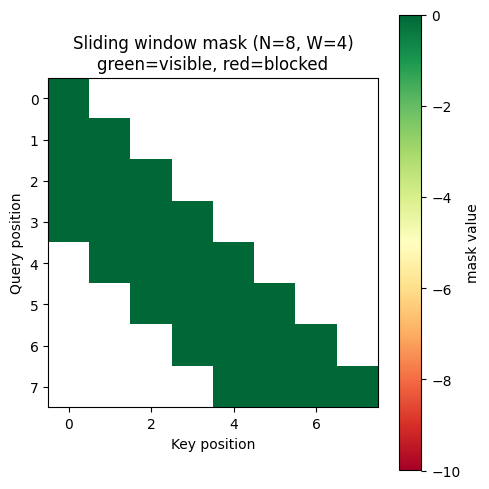

In [17]:
# Homework 2: implement the sliding window mask

import torch

def make_sliding_window_mask(N, W):
    """Build a causal + sliding window mask

    Returns an [N, N] tensor, 0 = allowed to attend, -inf = blocked
    """
    # TODO: complete this function
    # 1. causal mask: upper triangle (excluding the diagonal) filled with -inf
    # 2. sliding window: positions where (row - col) > W - 1 filled with -inf
    pass


# Verify
mask = make_sliding_window_mask(N=8, W=4)

# Check basic properties
assert mask.shape == (8, 8), f"shape should be (8, 8), got {mask.shape}"
# (0, 0) should be visible (self)
assert mask[0, 0] == 0, "(0, 0) should be visible"
# (3, 0) — distance 3, W=4 means the window covers W tokens, max distance W-1=3, so (3,0) should be visible
assert mask[3, 0] == 0, "(3, 0) distance 3, within window W=4, should be visible"
# (4, 0) should be invisible (distance 4, exceeds W-1=3)
assert mask[4, 0] == float('-inf'), "(4, 0) distance 4, exceeds window W=4, should be invisible"
# (i, j) where j > i should be -inf (causal)
assert mask[0, 1] == float('-inf'), "(0, 1) blocked by causality, should be invisible"

# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap='RdYlGn', vmin=-10, vmax=0)
plt.colorbar(label='mask value')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.title(f'Sliding Window Mask (N=8, W=4)\ngreen=visible, red=blocked')
plt.tight_layout()
plt.show()

print(f"✅ Homework 2 passed")
print(f"   Sliding window mask built correctly")


In [18]:
# Homework 3: top-N sparsity computation

N = 64
K = 8

# TODO: fill in the computation
total_entries = None    # N * N (total entries in the attention matrix)
sparse_entries = None   # N * K (entries actually computed)
sparsity = None         # sparse_entries / total_entries (smaller means more savings)

assert total_entries is not None
assert sparse_entries is not None
assert sparsity is not None

expected_total = N * N
expected_sparse = N * K
expected_sparsity = expected_sparse / expected_total

assert total_entries == expected_total
assert sparse_entries == expected_sparse
assert abs(sparsity - expected_sparsity) < 0.001

print(f"✅ Homework 3 passed")
print(f"   Attention matrix size: {N}x{N} = {total_entries:,} entries")
print(f"   Sparse actually computes: {N}x{K} = {sparse_entries:,} entries")
print(f"   Sparsity: {sparsity*100:.1f}% (only {sparsity*100:.0f}% of entries computed)")
print(f"   Key observation: sparsity = K/N = {K}/{N} = {K/N:.2f}")


Exercise passed: you have understood this step.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.